# **LAB ASSIGNMENT - 8**

**Install & Import Libraries**

In [17]:
# Install required libraries
!pip install nltk tensorflow keras matplotlib

# Import libraries
import numpy as np
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import gutenberg
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

# Download dataset
nltk.download('gutenberg')

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

**Load Dataset**

In [18]:
# Load Hamlet text
data = gutenberg.raw('shakespeare-hamlet.txt')

# Total words
words = data.split()
print("Total words:", len(words))

# Show first 10 lines
print("\nSample Text:\n")
print("\n".join(data.split("\n")[:10]))

Total words: 29605

Sample Text:

[The Tragedie of Hamlet by William Shakespeare 1599]


Actus Primus. Scoena Prima.

Enter Barnardo and Francisco two Centinels.

  Barnardo. Who's there?
  Fran. Nay answer me: Stand & vnfold
your selfe


**Preprocessing**

In [19]:
# Lowercase
data = data.lower()

# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts([data])

# Total words
total_words = len(tokenizer.word_index) + 1
print("Total unique words:", total_words)

Total unique words: 4818


**Sequence Generation**

In [20]:
input_sequences = []

for line in data.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

print("Total sequences:", len(input_sequences))

Total sequences: 25732


**Padding + Features**

In [21]:
# Max sequence length
max_seq_len = max([len(seq) for seq in input_sequences])

# Padding
input_sequences = pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre')

# Split into X and y
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

# Convert y into categorical
y = to_categorical(y, num_classes=total_words)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (25732, 13)
Shape of y: (25732, 4818)


**Build Model (LSTM)**

In [22]:
model = Sequential()

model.add(Embedding(total_words, 128, input_length=max_seq_len-1))
model.add(LSTM(200, return_sequences=True))
model.add(LSTM(150))
model.add(Dense(total_words, activation='softmax'))

**Train Model**

In [25]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(X, y, epochs=50, verbose=1)

Epoch 1/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.0350 - loss: 6.8496
Epoch 2/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.0416 - loss: 6.4463
Epoch 3/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.0509 - loss: 6.2573
Epoch 4/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.0637 - loss: 6.0549
Epoch 5/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.0736 - loss: 5.8601
Epoch 6/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.0827 - loss: 5.6892
Epoch 7/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.0883 - loss: 5.5308
Epoch 8/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.0947 - loss: 5.3715
Epoch 9/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.1026 - loss: 5.2117
Epoch 10/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1101 - loss: 5.0476
Epoch 11/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.1165 - loss: 4.8837
Epoch 12/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/s

**Plot Loss**

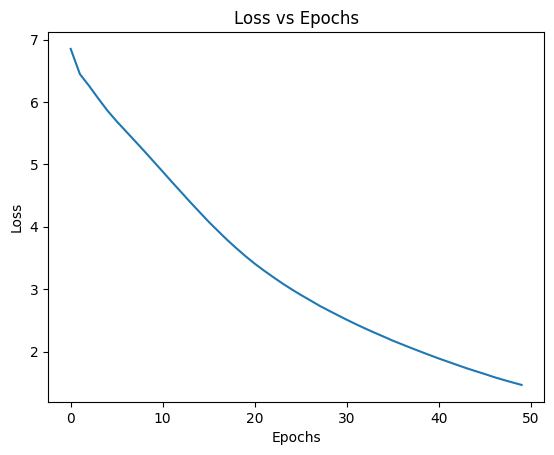

In [26]:
plt.plot(history.history['loss'])
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

**Next Word Prediction Function**

In [27]:
def predict_next_word(seed_text):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')

    predicted = np.argmax(model.predict(token_list), axis=-1)[0]

    for word, index in tokenizer.word_index.items():
        if index == predicted:
            return seed_text + " " + word

    return seed_text

**Test Predictions**

In [31]:
print(predict_next_word("to be or not to"))
print(predict_next_word("the king is"))
print(predict_next_word("i love"))
print(predict_next_word("he is"))
print(predict_next_word("what is"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
to be or not to cause
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
the king is dead
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
i love haue
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
he is gone
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
what is the


**Summary:** We built a simple AI model that learns from Shakespeare’s Hamlet and predicts the next word in a sentence, similar to Google Autocomplete. We first cleaned and converted the text into numbers, then created sequences so the model could understand word patterns. After training an LSTM-based neural network on this data, the model was able to take a few words as input and intelligently guess the next word based on what it learned.